In [1]:
import numpy as np
import matplotlib.pyplot as plt
import nnfs_3 as k1

nnfs_3
epochs:0, accuracy:0.360, loss:1.098594, lr: -1.0 
epochs:1, accuracy:0.400, loss:1.098574, lr: -0.9990009990009991 
epochs:2, accuracy:0.393, loss:1.098544, lr: -0.998003992015968 
epochs:3, accuracy:0.417, loss:1.098509, lr: -0.9970089730807579 
epochs:4, accuracy:0.423, loss:1.098470, lr: -0.9960159362549801 
epochs:5, accuracy:0.417, loss:1.098429, lr: -0.9950248756218907 
epochs:6, accuracy:0.413, loss:1.098379, lr: -0.9940357852882704 
epochs:7, accuracy:0.410, loss:1.098316, lr: -0.99304865938431 
epochs:8, accuracy:0.423, loss:1.098235, lr: -0.9920634920634921 
epochs:9, accuracy:0.410, loss:1.098136, lr: -0.9910802775024778 
epochs:10, accuracy:0.417, loss:1.098012, lr: -0.9900990099009901 
epochs:11, accuracy:0.423, loss:1.097857, lr: -0.9891196834817014 
epochs:12, accuracy:0.420, loss:1.097661, lr: -0.9881422924901185 
epochs:13, accuracy:0.423, loss:1.097416, lr: -0.987166831194472 
epochs:14, accuracy:0.417, loss:1.097110, lr: -0.9861932938856016 
epochs:15, accura

Training sample data from spiral points

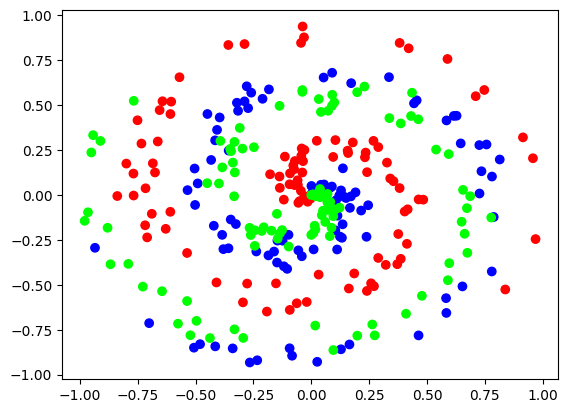

In [8]:
import nnfs
from nnfs.datasets import spiral_data

nnfs.init()
X, y = spiral_data(samples=100, classes=3)
plt.scatter(X[:, 0], X[:, 1], c=y,cmap='brg')

In [2]:
Y3 = np.arange(-1, 1, 0.005).tolist()
X3 = np.arange(-1, 1, 0.005)
ln = len(X3)
X3 = X3.repeat(len(Y3))
Y3 = np.array(Y3 * ln)

pairs = np.array([[x, y] for x, y in zip(X3, Y3)])

layer1 = k1.layer1
activation1 = k1.activation1
layer2 = k1.layer2
activation2 = k1.activation2

layer1.forward(pairs)
activation1.forward(layer1.output)
layer2.forward(activation1.output)
activation2.forward(layer2.output)

predictions = np.argmax(activation2.output, axis=1)
print(f'accuracy: {k1.accuracy:.3f}')


accuracy: 0.960


In [3]:
x_min, x_max = k1.X[:,0].min() - 0.3, k1.X[:,0].max() + 0.3
y_min, y_max = k1.X[:,1].min() - 0.3 , k1.X[:,1].max() + 0.3

xx, yy = np.meshgrid(np.linspace(x_min, x_max, 500), np.linspace(y_min, y_max, 500))

pairs = np.c_[xx.ravel(), yy.ravel()]

layer1 = k1.layer1
activation1 = k1.activation1
layer2 = k1.layer2
activation2 = k1.activation2

layer1.forward(pairs)
activation1.forward(layer1.output)
layer2.forward(activation1.output)
activation2.forward(layer2.output)

predictions = np.argmax(activation2.output, axis=1)
print(f'accuracy: {k1.accuracy:.3f}')


accuracy: 0.960


Neural networks learning boundary after training

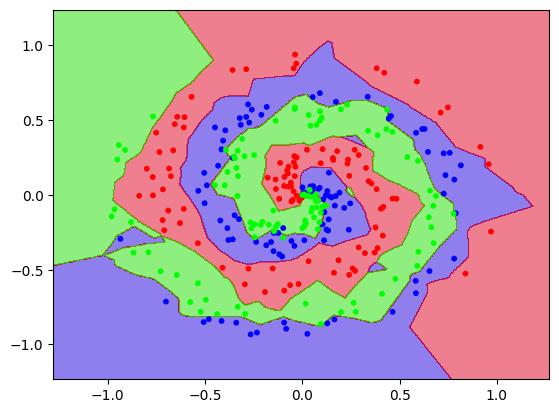

In [4]:
Z = predictions.reshape(xx.shape)

# ploting over the meshgrid
plt.contourf(xx, yy, Z, alpha = 0.5, cmap='brg')
a = plt.scatter(k1.X[:, 0], k1.X[:, 1], c=k1.y, cmap='brg')
a.set_sizes([10])

